## Read the data & inital exploration

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('Data/Global_Smartwatch_Marketplace_Insights_2026.csv')

In [3]:
df.columns

Index(['brand', 'condition', 'Case_Size_mm', 'Country', 'price', 'Seller_ID',
       'Is_Worldwide_Shipping', 'title'],
      dtype='object')

In [4]:
df.shape

(3607, 8)

In [5]:
df.describe()

,Case_Size_mm,price,Is_Worldwide_Shipping
count,2729.000000,3607.000000,3607.000000
mean,45.942836,617.819739,0.273357
std,3.165700,1071.008291,0.445745
min,26.000000,120.000000,0.000000
25%,44.000000,458.745000,0.000000
50%,46.000000,550.000000,0.000000
75%,49.000000,699.000000,1.000000
max,52.000000,49900.000000,1.000000


In [6]:
df.head(10)

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
0,Garmin,Used,NaN,Japan,999.76,Seller_0001,1,Garmin fenix 7 Pro Sapphire Dual Power Watch 4...
1,Garmin,Used,NaN,Japan,928.00,Seller_0002,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
2,Garmin,Used,50.0,Japan,934.92,Seller_0001,1,Garmin Fenix 7X Pro Solar Sapphire 50mm GPS Mu...
3,Garmin,New,NaN,Canada,1200.00,Seller_0003,0,garmin tactix 7 amoled edition BNIB
4,Garmin,Used,43.0,Japan,962.08,Seller_0001,1,Garmin Descent MK2S GPS Watch 43mm Light Sand ...
5,Garmin,Used,NaN,Japan,902.28,Seller_0001,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
6,Garmin,Used,NaN,Japan,913.36,Seller_0001,1,Garmin Venu X1 Black Smartwatch GPS Multisport...
7,Garmin,Used,47.0,Japan,911.44,Seller_0001,1,Garmin Venu X1 AMOLED Sapphire Titanium 47mm G...
8,Garmin,Used,NaN,Japan,908.06,Seller_0001,1,Garmin Epix GPS Porsche Design Smartwatch
9,Garmin,Used,NaN,Japan,884.90,Seller_0001,1,Garmin Tacx FLUX S Smart Direct Drive Trainer ...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  3607 non-null   object 
 1   condition              3607 non-null   object 
 2   Case_Size_mm           2729 non-null   float64
 3   Country                3607 non-null   object 
 4   price                  3607 non-null   float64
 5   Seller_ID              3607 non-null   object 
 6   Is_Worldwide_Shipping  3607 non-null   int64  
 7   title                  3607 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 225.6+ KB


#### Missing value: Case_Size_mm


In [8]:
print(df.nunique())

brand                       5
condition                  14
Case_Size_mm               15
Country                    27
price                    1117
Seller_ID                1754
Is_Worldwide_Shipping       2
title                    3179
dtype: int64


#### Cần chuyển sang dạng category: Brand, Condition, Country

In [9]:
convert_category= ['brand', 'condition', 'Country']
for col in convert_category:
    df[col]= df[col].astype('category')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   brand                  3607 non-null   category
 1   condition              3607 non-null   category
 2   Case_Size_mm           2729 non-null   float64 
 3   Country                3607 non-null   category
 4   price                  3607 non-null   float64 
 5   Seller_ID              3607 non-null   object  
 6   Is_Worldwide_Shipping  3607 non-null   int64   
 7   title                  3607 non-null   object  
dtypes: category(3), float64(2), int64(1), object(2)
memory usage: 153.7+ KB


#### Fill missing values

In [11]:
df['Case_Size_mm']=df['Case_Size_mm'].fillna(df.groupby('brand', observed=True)['Case_Size_mm'].transform('median'))
print(f"Số giá trị thiếu còn lại: {df['Case_Size_mm'].isnull().sum()}")

Số giá trị thiếu còn lại: 0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   brand                  3607 non-null   category
 1   condition              3607 non-null   category
 2   Case_Size_mm           3607 non-null   float64 
 3   Country                3607 non-null   category
 4   price                  3607 non-null   float64 
 5   Seller_ID              3607 non-null   object  
 6   Is_Worldwide_Shipping  3607 non-null   int64   
 7   title                  3607 non-null   object  
dtypes: category(3), float64(2), int64(1), object(2)
memory usage: 153.7+ KB


## Part 1: EDA

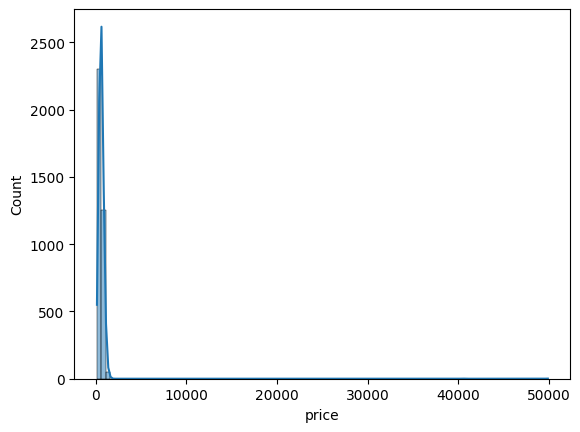

In [13]:
sns.histplot(data= df, x='price', bins=100, kde=True);

#### Có giá trị ngoại lệ ở đây khi chủ yếu giá đồng hồ chỉ tập trung khoảng <5000 nhưng có những đồng hồ trị giá 50000

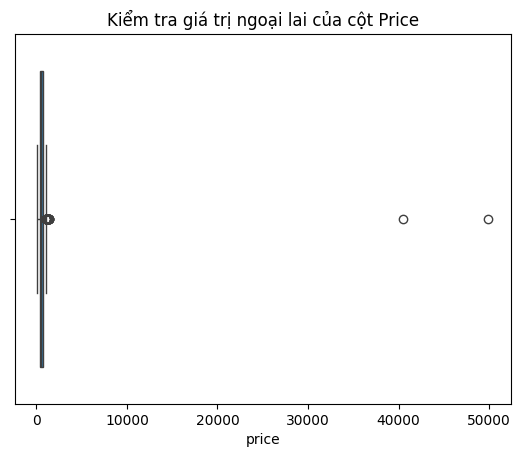

In [14]:
sns.boxplot(data=df, x='price')
plt.title('Kiểm tra giá trị ngoại lai của cột Price')
plt.show()

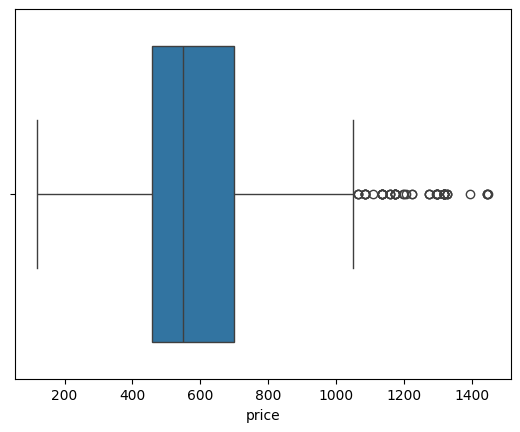

In [15]:
sns.boxplot(data=df[df['price'] < 2000], x='price');

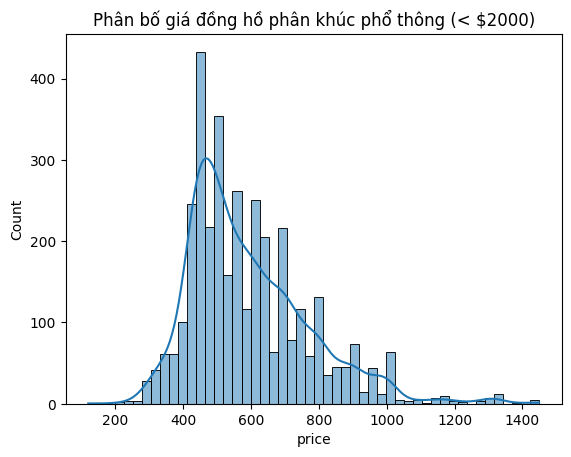

In [16]:
df_filtered = df[df['price'] < 2000]
sns.histplot(data=df_filtered, x='price', bins=50, kde=True)
plt.title('Phân bố giá đồng hồ phân khúc phổ thông (< $2000)')
plt.show()

#### Ở đây cho thấy giá đồng hồ chủ yếu phân bố khoảng 420$-700$

In [17]:
df[df['price'] > 10000]

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
1662,Apple,Usado,49.0,Estados Unidos,40500.0,Seller_0751,0,"Apple Watch Ultra 2 49mm Titânio, Azul/Preto, ..."
2524,Samsung,Novo,47.0,Estados Unidos,49900.0,Seller_1215,0,Smartwatch (2025) SAMSUNG Galaxy Watch Ultra 4...


#### Chỉ có 2 sản phẩm có giá tiền vượt trội so với các sản phẩm khác
    * Có thể là do lỗi nhập dữ liệu vì dù đồng hồ có mạ vàng hay gì cũng không thể lên con số 40000 được
    * Giải pháp ở đây là xoá luôn 2 sản phẩm đó khỏi df

In [18]:
df=df[df['price']<10000]

In [19]:
df_filtered.value_counts()

brand   condition                Case_Size_mm  Country         price   Seller_ID    Is_Worldwide_Shipping  title                                                                           
Apple   Excellent - Refurbished  49.0          United States   839.95  Seller_0033  0                      Apple Watch Ultra 2 [GPS + Cellular 49mm] Smartwatch with Rugged Titanium Case &    6
Garmin  New                      41.0          United States   560.99  Seller_0033  0                      Garmin Venu 4, 41mm, Advanced Health and Fitness GPS Smartwatch, Bright and         5
Apple   New                      49.0          United States   839.95  Seller_0033  0                      Apple Watch Ultra 2 [GPS + Cellular 49mm] Smartwatch with Rugged Titanium Case &    4
        Open box                 49.0          United States   450.00  Seller_1270  0                      Apple Watch Ultra 2 49mm Titanium, GPS + Cellular (Open Box)                        4
Garmin  New                      45.0   

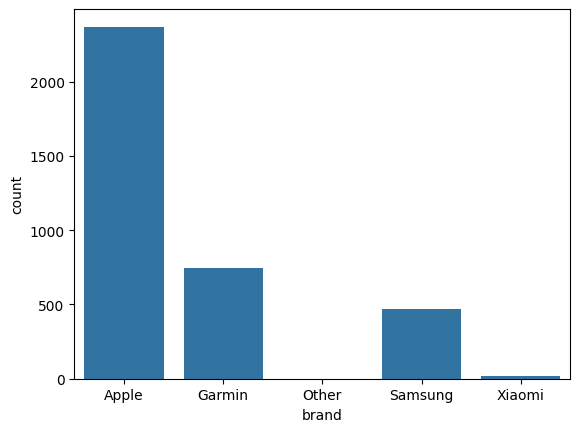

In [20]:
sns.countplot(data=df, x='brand');

In [21]:
df['brand'].unique()

['Garmin', 'Apple', 'Samsung', 'Xiaomi', 'Other']
Categories (5, object): ['Apple', 'Garmin', 'Other', 'Samsung', 'Xiaomi']

In [22]:
brand_counts = df['brand'].value_counts(normalize=True) * 100
print(brand_counts)

brand
Apple      65.714286
Garmin     20.693481
Samsung    13.009709
Xiaomi      0.554785
Other       0.027739
Name: proportion, dtype: float64


#### Từ đây cho thấy Apple chiếm tỉ lệ rất cao khi đến tận 65.7% trong kho Xiaomi hay Other chỉ <1%

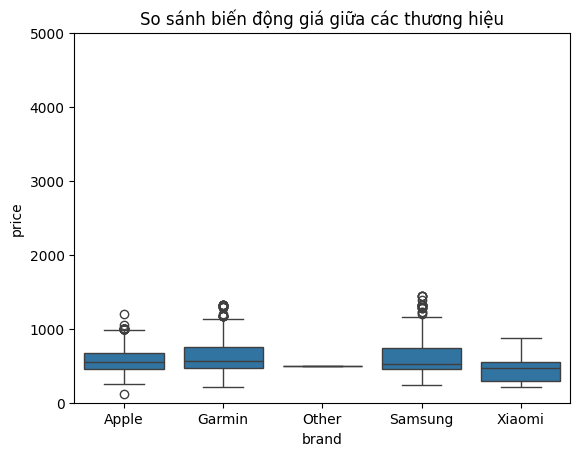

In [23]:
#plt.figure(figsize=(10, 6))
sns.boxplot(x='brand', y='price', data=df);
plt.title('So sánh biến động giá giữa các thương hiệu')
plt.ylim(0, 5000)
plt.show()

#### Gộp Xiaomi vào Other do cả 2 tỉ lệ % quá thấp

In [24]:
df['brand'] = df['brand'].astype(str)
df['brand'] = df['brand'].replace(['Xiaomi', 'Other brand', 'Other'], 'Small brand')
df['brand'] = df['brand'].astype('category')
print(df['brand'].value_counts())

brand
Apple          2369
Garmin          746
Samsung         469
Small brand      21
Name: count, dtype: int64


In [25]:
print(df['condition'].value_counts())

condition
New                         1553
Used                        1250
Open box                     581
Excellent - Refurbished      118
Very Good - Refurbished       40
For parts or not working      21
Good - Refurbished            20
New other                      5
Nuevo                          5
Certified - Refurbished        4
Usado                          4
Caja abierta                   3
--                             1
Novo                           0
Name: count, dtype: int64


#### Ở condition có nhiều loại ngôn ngữ khác nhau, chưa kể phần Refurbished lại bị chia nhỏ quá mức

In [26]:
df['condition']=df['condition'].astype(str)
condition_map={
    'New': 'New', 'Nuevo': 'New', 'Novo': 'New', 'New other': 'New',
    'Used': 'Used', 'Usado': 'Used',
    'Open box': 'Open Box', 'Caja abierta': 'Open Box',
    'Excellent - Refurbished': 'Refurbished',
    'Very Good - Refurbished': 'Refurbished',
    'Good - Refurbished': 'Refurbished',
    'Certified - Refurbished': 'Refurbished',
    'For parts or not working': 'Broken/Other',
    '--': 'Broken/Other'
    }
df['condition']=df['condition'].replace(condition_map)
df['condition']=df['condition'].astype('category')  
df['condition'].value_counts()

condition
New             1563
Used            1254
Open Box         584
Refurbished      182
Broken/Other      22
Name: count, dtype: int64

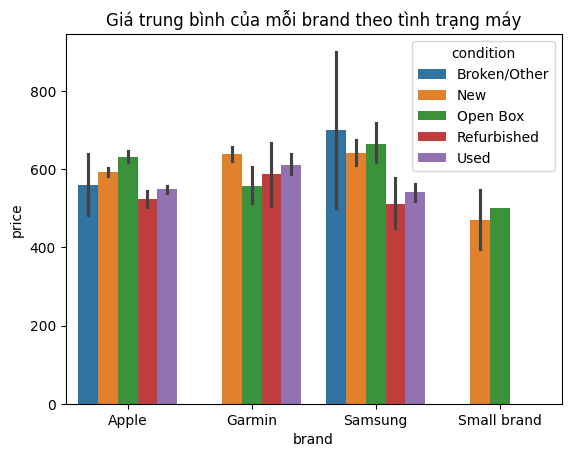

In [27]:
sns.barplot(data=df, x='brand', y='price', hue='condition')
plt.title('Giá trung bình của mỗi brand theo tình trạng máy')
plt.show()

#### Từ biểu đồ cho thấy Apple giữ giá khá tốt khi mức giá chênh lệch giữa New hay Used là tương đối thấp

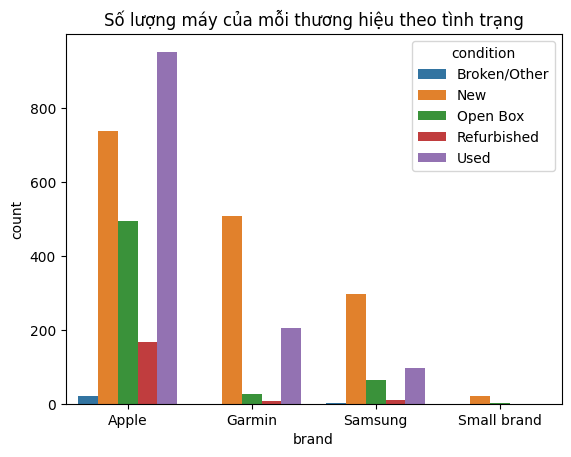

In [28]:
sns.countplot(data=df, x='brand', hue='condition');
plt.title('Số lượng máy của mỗi thương hiệu theo tình trạng');

Điều này cho thấy thị trường Smartwatch cũ của Apple cực kỳ sôi động. Người dùng có xu hướng mua đi bán lại Apple Watch rất nhiều so với các hãng khác

In [29]:
df.groupby(['brand', 'condition'], observed=True)['price'].describe()

count        mean         std     min       25%  \
brand       condition                                                       
Apple       Broken/Other   20.0  558.161000  184.296384  314.99  429.0000   
            New           737.0  592.473202  148.591682  274.95  468.0000   
            Open Box      494.0  632.071437  168.162108  299.99  499.2475   
            Refurbished   166.0  523.442169  135.905699  120.00  429.0000   
            Used          952.0  547.943141  139.557030  249.99  450.0000   
Garmin      New           508.0  638.868583  206.930061  215.10  479.6800   
            Open Box       26.0  556.780000  117.995818  425.00  495.6225   
            Refurbished     7.0  588.268571  125.550269  419.00  494.9950   
            Used          205.0  611.623024  182.519542  280.00  445.0000   
Samsung     Broken/Other    2.0  700.000000  282.842712  500.00  600.0000   
            New           298.0  639.931074  274.700104  244.99  442.5250   
            Open Box       63.0  665.266825  202.194857  309.99  489.9950   
            Refurbished     9.0  511.101111  105.409257  399.99  450.0000   
            Used           97.0  540.931443  118.788378  350.00  450.0000   
Small brand New            20.0  468.981500  178.540613  213.53  290.9350   
            Open Box        1.0  499.990000         NaN  499.99  499.9900   

                              50%       75%      max  
brand       condition                                 
Apple       Broken/Other  509.970  619.9900   999.99  
            New           589.980  700.0000  1000.00  
            Open Box      609.475  722.2500  1199.00  
            Refurbished   489.990  627.9875   896.99  
            Used          502.145  600.0000  1050.00  
Garmin      New           567.450  749.9900  1319.00  
            Open Box      500.000  599.9975   900.00  
            Refurbished   579.990  704.4750   719.95  
            Used          577.960  780.3800   999.76  
Samsung     Broken/Other  700.000  800.0000   900.00  
            New           522.500  764.3175  1449.00  
            Open Box      675.000  799.0000  1000.00  
            Refurbished   450.000  649.9900   649.99  
            Used          517.500  597.9100   968.39  
Small brand New           463.990  545.0000   875.00  
            Open Box      499.990  499.9900   499.99

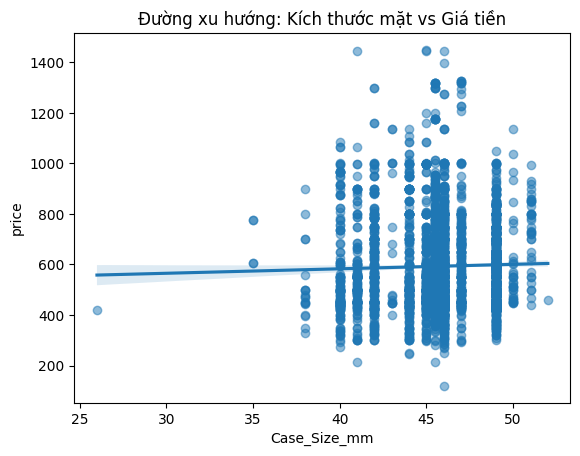

In [30]:
sns.regplot(data=df, x='Case_Size_mm', y='price', scatter_kws={'alpha':0.5})
plt.title('Đường xu hướng: Kích thước mặt vs Giá tiền')
plt.show()

#### Ở đây cho thấy sơ bộ về sự tương quan giữa kích thước và giá tiền

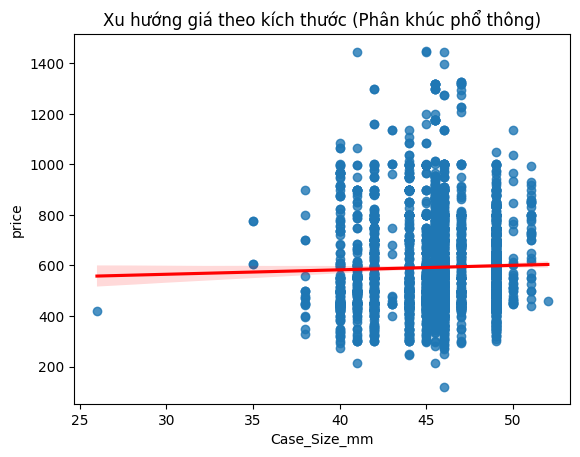

In [31]:
df_zoom = df[df['price'] < 5000]
sns.regplot(data=df_zoom, x='Case_Size_mm', y='price', line_kws={"color": "red"})
plt.title('Xu hướng giá theo kích thước (Phân khúc phổ thông)');

#### Sau khi xem xét ở phân khúc phổ thông. Ta chứng minh được rằng sự tương quan giữa kích thước và giá tiền là rất thấp vì vậy giá tiền không phụ thuộc vào kích thước

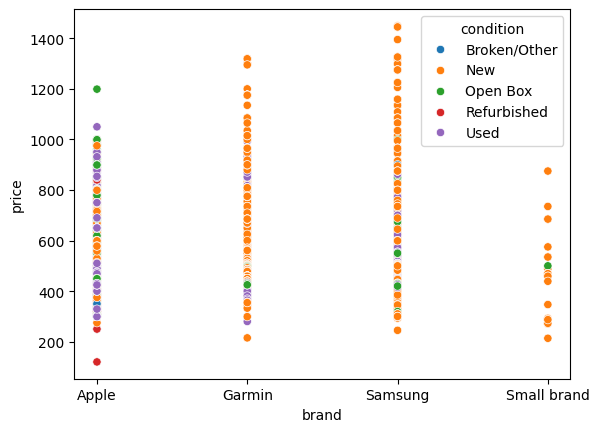

In [32]:
sns.scatterplot(data=df, x='brand', y='price', hue='condition');

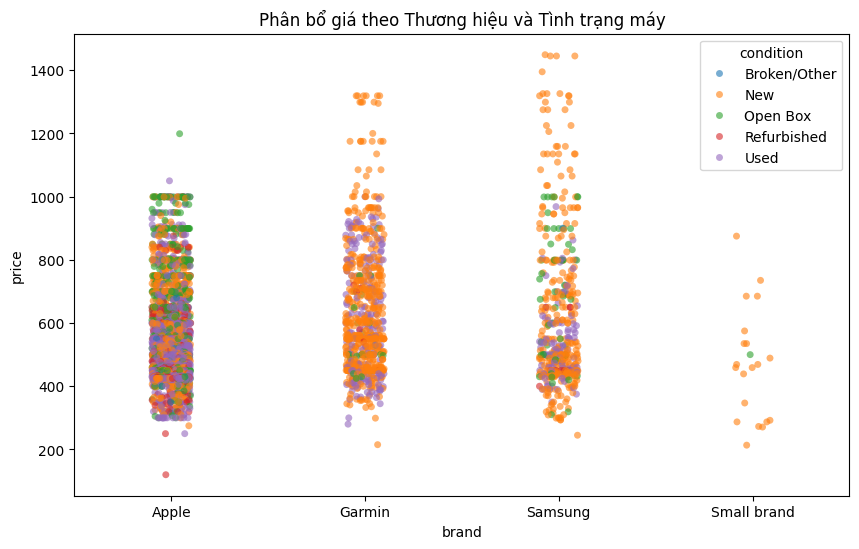

In [33]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='brand', y='price', hue='condition', jitter=True, alpha=0.6)
plt.title('Phân bổ giá theo Thương hiệu và Tình trạng máy')
plt.show()

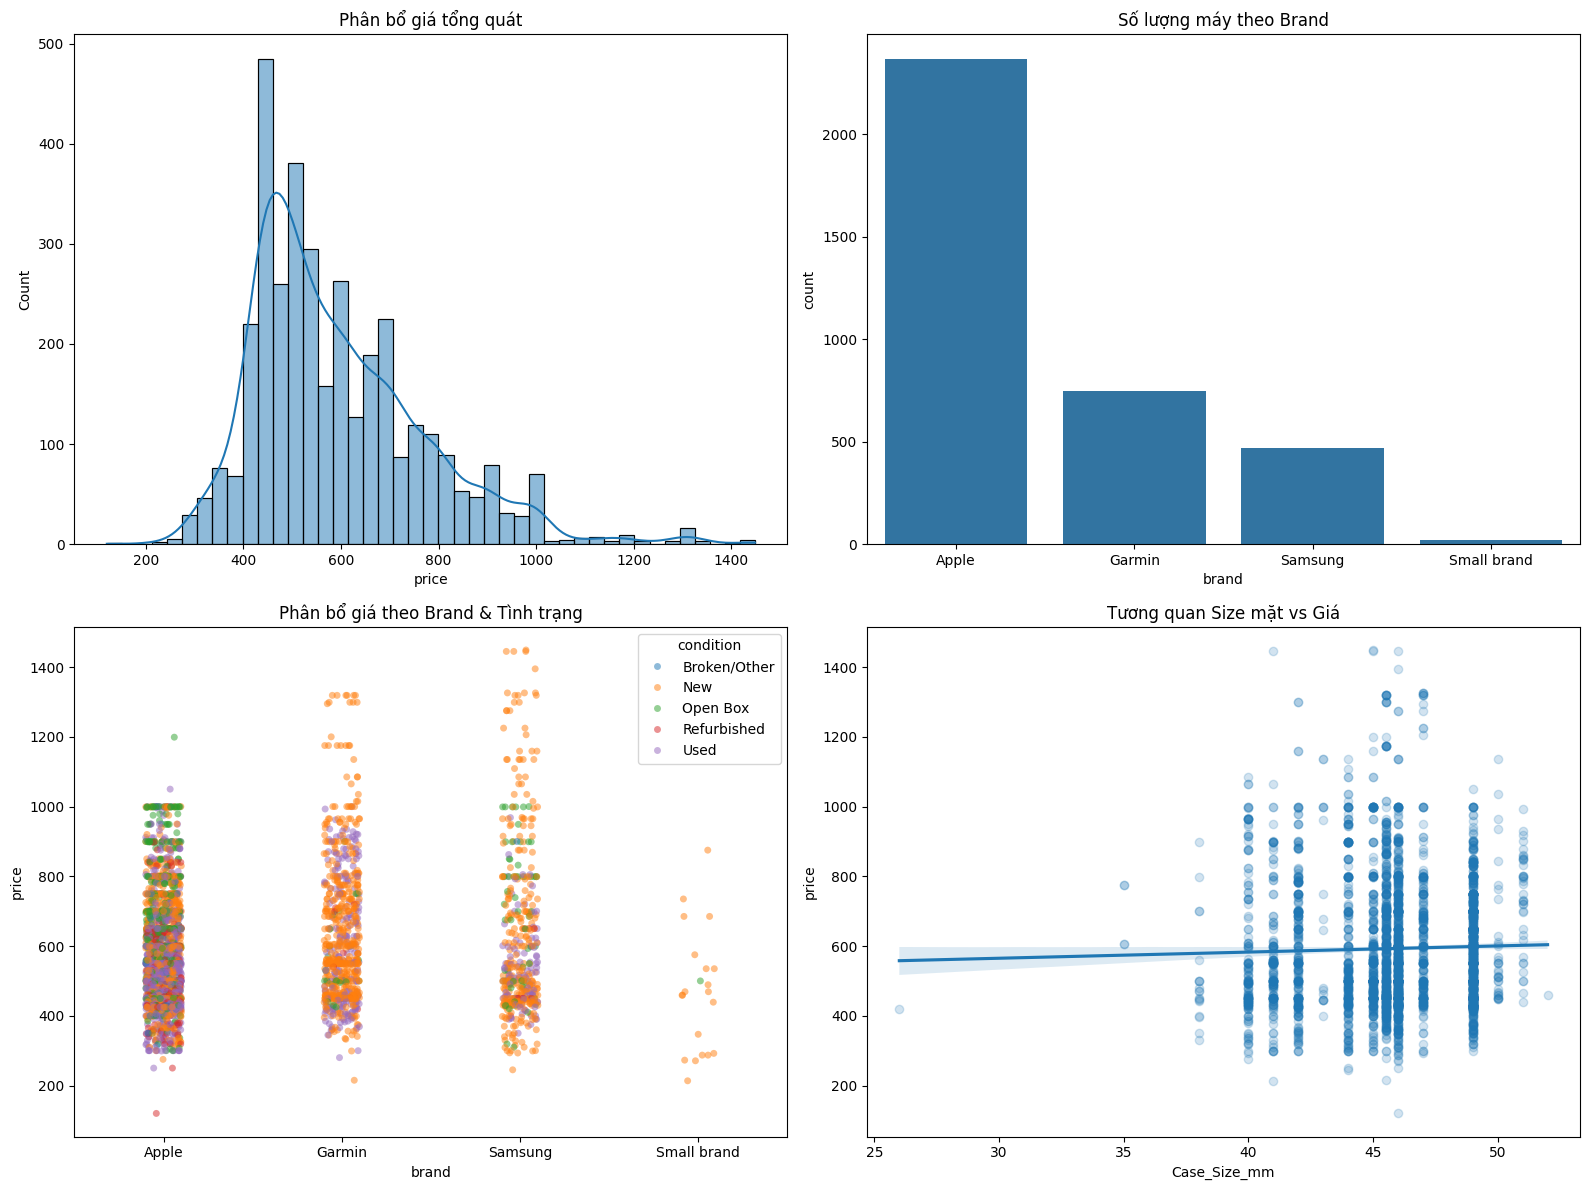

In [34]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

sns.histplot(data=df, x='price', kde=True, ax=ax1)
ax1.set_title('Phân bổ giá tổng quát')

sns.countplot(data=df, x='brand', ax=ax2)
ax2.set_title('Số lượng máy theo Brand')

sns.stripplot(data=df, x='brand', y='price', hue='condition', jitter=True, alpha=0.5, ax=ax3)
ax3.set_title('Phân bổ giá theo Brand & Tình trạng')

sns.regplot(data=df, x='Case_Size_mm', y='price', scatter_kws={'alpha':0.2}, ax=ax4)
ax4.set_title('Tương quan Size mặt vs Giá')

plt.tight_layout()
plt.show()

#### Dùng subplot theo hướng đối tượng để gom các biểu đồ trên cùng một khung hình

In [35]:
print(df['Country'].value_counts().head(10))

Country
United States     2344
United Kingdom     469
South Korea        212
Japan              185
Italy              131
Canada              87
Germany             37
Malaysia            25
Hong Kong           24
Australia           23
Name: count, dtype: int64


#### Từ đây ta nghi ngờ Apple sẽ có ở United States do Apple có nguồn gốc từ United States

In [36]:
top_countries = df['Country'].value_counts().nlargest(5).index
df['Country'] = df['Country'].astype(str)
df.loc[~df['Country'].isin(top_countries), 'Country'] = 'Other countries'
df['Country'] = df['Country'].astype('category')

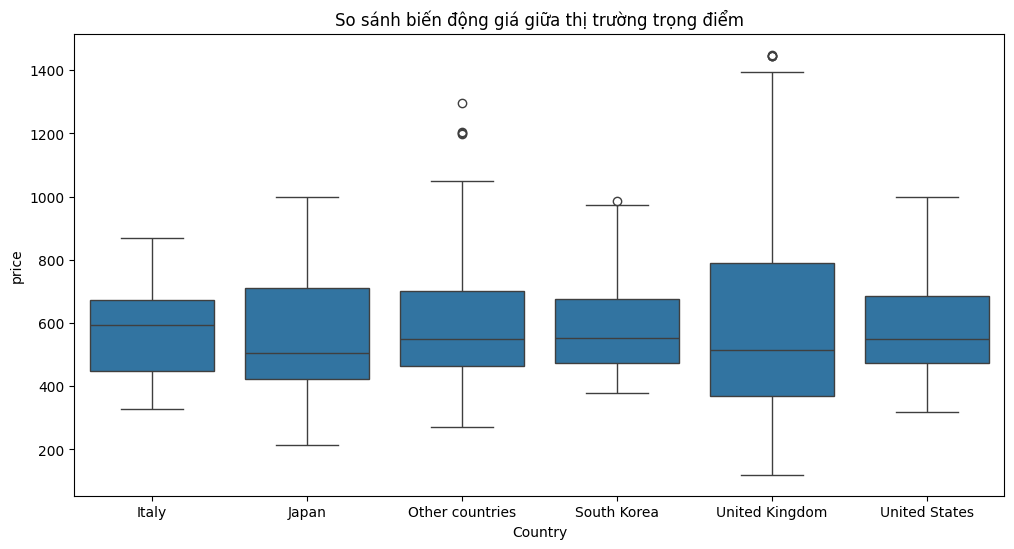

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Country', y='price');
plt.title('So sánh biến động giá giữa thị trường trọng điểm')
plt.show()

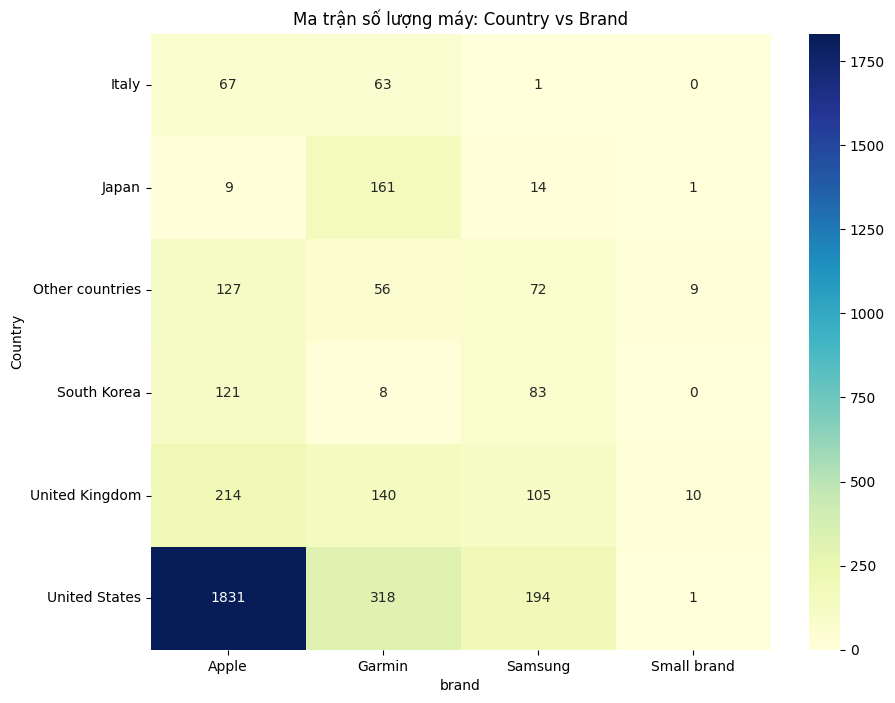

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(pd.crosstab(df['Country'], df['brand']), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Ma trận số lượng máy: Country vs Brand')
plt.show()

#### Heatmap đã kiểm chứng được sự nghi ngờ này là hoàn toàn chính xác